<a href="https://colab.research.google.com/github/Alezgo-ui/Hipotesis_pruebas_estadisticas/blob/main/Experimento_pruebas_estadisticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivo
df = pd.read_csv('https://raw.githubusercontent.com/Alezgo-ui/Hipotesis_pruebas_estadisticas/refs/heads/main/data/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:
- El dataset no tiene valores ausentes. (Todas las columnas reflejan exactamente 40,000 valores)
- La columna date es de tipo de dato object y debería de ser datetime64. Convertir la columna para poder realizar análisis temporales correctos (por ejemplo, ver la evolución de conversiones por día o semana).
- La columna converted es de tipo de dato int64 y podría optimizarse a int8 o bool. Como solo almacena valores binarios (0 y 1), mantenerla en un entero de 64 bits consume memoria innecesaria. Cambiarla a un tipo de dato más ligero optimizará el dataframe.
- Las columnas landing, region, dispositivo, traffic_source y user_type son de tipo de dato object y deberían de ser category.
- La columna converted - converted es de tipo de dato int64 y podría optimizarse a int8 o bool. Como solo almacena valores binarios (0 y 1), mantenerla en un entero de 64 bits consume espacio de almacenamiento innecesario. Cambiarla a un tipo de dato más ligero optimizará el DataFrame.

In [ ]:
# 1. Crear una copia explícita para no alterar el DataFrame original
df_clean = df.copy()

# 2. Convertir fecha a datetime en la copia
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 3. Convertir columnas de texto a categorías en la copia
categorical_cols = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
df_clean[categorical_cols] = df_clean[categorical_cols].astype('category')

# 4. Optimizar la variable binaria de conversión en la copia
df_clean['converted'] = df_clean['converted'].astype('int8')

# Verificar los cambios aplicados en el nuevo DataFrame limpio
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         40000 non-null  object        
 1   date            40000 non-null  datetime64[ns]
 2   landing         40000 non-null  category      
 3   region          40000 non-null  category      
 4   dispositivo     40000 non-null  category      
 5   traffic_source  40000 non-null  category      
 6   user_type       40000 non-null  category      
 7   converted       40000 non-null  int8          
 8   gasto           40000 non-null  float64       
dtypes: category(5), datetime64[ns](1), float64(1), int8(1), object(1)
memory usage: 1.1+ MB


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
# 1. Contar el número de usuarios únicos en la columna user_id
usuarios_unicos = df_clean['user_id'].nunique()
total_filas = len(df_clean)

print(f"Total de registros en el DataFrame: {total_filas}")
print(f"Total de usuarios únicos: {usuarios_unicos}")

# 2. Verificar si existen duplicados
if usuarios_unicos == total_filas:
    print("✅ ¡Perfecto! Cada fila corresponde a un usuario único. No hay duplicados.")
else:
    print(f"⚠️ Atención: Hay {total_filas - usuarios_unicos} registros duplicados.")

Total de registros en el DataFrame: 40000
Total de usuarios únicos: 40000
✅ ¡Perfecto! Cada fila corresponde a un usuario único. No hay duplicados.


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df_clean["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df_clean["date"].min())
print("Fecha máxima:", df_clean["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df_clean['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df_clean[df_clean['gasto'] > 0]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
# Lista de variables categóricas de segmentación
cat_cols = ['region', 'dispositivo', 'traffic_source', 'user_type']

print("=== DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ===\n")

for col in cat_cols:
    print(f"--- Distribución para la columna {col} ---")
    # Crear un DataFrame temporal para mostrar conteo y porcentaje juntos
    frecuencia = df_clean[col].value_counts()
    porcentaje = df_clean[col].value_counts(normalize=True) * 100

    df_dist = pd.DataFrame({'Conteo': frecuencia, 'Porcentaje (%)': porcentaje})
    display(df_dist)
    print("\n" + "="*40 + "\n")


Conteo de categorías:
=== DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ===

--- Distribución para la columna region ---


,Conteo,Porcentaje (%)
Norte,11166,27.9150
Centro,9613,24.0325
Sur,8039,20.0975
Occidente,6398,15.9950
Oriente,4784,11.9600




--- Distribución para la columna dispositivo ---


,Conteo,Porcentaje (%)
Mobile,24829,62.0725
Desktop,15171,37.9275




--- Distribución para la columna traffic_source ---


,Conteo,Porcentaje (%)
Organic,17987,44.9675
Ads,11935,29.8375
Email,6123,15.3075
Referral,3955,9.8875




--- Distribución para la columna user_type ---


,Conteo,Porcentaje (%)
Nuevo,26033,65.0825
Recurrente,13967,34.9175


✍️ **Comentario**:

Todas las columnas tienen valores esperados. Las etiquetas en las columnas region, dispositivo, traffic_source y user_type son consistentes, están bien escritas y no muestran categorías duplicadas por errores de dedo o problemas de capitalización.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión (filtrando solo usuarios que se convirtieron)
gasto_A = df_clean[(df_clean['landing'] == 'A') & (df_clean['converted'] == 1)]['gasto']
gasto_B = df_clean[(df_clean['landing'] == 'B') & (df_clean['converted'] == 1)]['gasto']
# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba

**Hipótesis:**

In [ ]:
from scipy.stats import levene

# Prueba de varianzas iguales
l_stat, p_value_var = levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")

Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08


In [ ]:
alpha = 0.05  # umbral de significancia

if p_value_var < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")

Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).


In [ ]:
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")
print()

alpha = 0.05   # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadístico t: -9.48101092267275
Valor p: 3.627602231521493e-21

Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. Existe evidencia estadística altamente significativa ($p = 3.62 \times 10^{-21}$, la cual es considerablemente menor que el umbral $\alpha = 0.05$) para afirmar que las varianzas son heterogéneas y que el gasto promedio entre ambos grupos no es igual.

**Interpretación de negocio:**  
Los resultados indican que la versión de la Página B está asociada con un valor económico significativamente mayor para el negocio en comparación con la Página A, cuando se analiza exclusivamente el segmento de usuarios que se convirtieron en clientes. El estadístico $t$ notablemente negativo ($-9.48$) confirma que el gasto promedio por cliente de la versión B supera de forma contundente al de la versión A, con un Porcentaje de confianza superior al 99%.

Este análisis demuestra una correlación estadística fuerte y una diferencia de rendimiento clara entre ambos grupos bajo las condiciones del experimento. Sin embargo, desde un sentido estadístico estricto, este reporte no asegura causalidad directa ni garantiza que el cambio exclusivo de la página sea el único factor detrás del incremento del gasto, ya que podrían existir variables externas no controladas o comportamientos estacionales influyendo en la conversión.

Desde una perspectiva estratégica, y asumiendo que el diseño experimental controló la aleatorización de manera correcta, se recomienda proceder con la implementación de la Página B, ya que ha demostrado ser la variante ganadora para maximizar el ticket promedio de compra o la monetización por usuario convertido.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba

**Hipótesis:**

In [ ]:
# Número de usuarios convertidos por página
conversiones = df_clean.groupby('landing')['converted'].sum()
totales = df_clean.groupby('landing')['converted'].count()

# Pasar los valores a formato lista
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

# Imprimir los resultados de forma clara
print("Usuarios convertidos por página (A vs B):")
print(exitos)

print("\nTotal de usuarios por página (A vs B):")
print(observaciones)


Usuarios convertidos por página (A vs B):
[2512.0, 3194.0]

Total de usuarios por página (A vs B):
[19982, 20018]


In [ ]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. Existe evidencia estadística contundente ($p = 3.76 \times 10^{-22}$, valor sustancialmente menor que el umbral $\alpha = 0.05$) para afirmar que la tasa de conversión entre la página A y la página B no es igual, respaldando este resultado con un porcentaje de confianza superior al 99%.

**Interpretación de negocio:**  
Los resultados demuestran que la versión de la Página B está asociada con un incremento estadísticamente significativo en la tasa de conversión de usuarios en comparación con la Página A. El estadístico $z$ notablemente negativo ($-9.67$) confirma el liderazgo de la variante B en la adquisición y retención de usuarios dentro del embudo de conversión.

Este análisis demuestra una correlación estadística sólida y una clara diferencia de rendimiento a favor de la Página B bajo las condiciones controladas del test. Sin embargo, este reporte no asegura causalidad directa ni descarta por completo la influencia latente de variables externas o factores de estacionalidad que pudieran haber interactuado de forma asimétrica durante el periodo de recolección de los datos.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba

**Hipótesis:**

In [ ]:
tabla = pd.crosstab(df_clean['traffic_source'], df_clean['converted'])
print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [ ]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula. Existe evidencia estadística significativa ($\text{Valor P} = 0.034 < \alpha = 0.05$) con 3 grados de libertad para confirmar que la conversión de los usuarios depende de su fuente de tráfico (traffic_source). Los resultados se respaldan con un porcentaje de confianza del 96%.

**Interpretación de negocio:**  
El análisis de las frecuencias esperadas revela que la asociación detectada no es uniforme entre todos los canales de adquisición. Las campañas de Ads (+56 conversiones reales sobre lo esperado) y las estrategias de Email (+44 conversiones reales sobre lo esperado) están sobre-performando, actuando como los motores principales que impulsan la tasa de conversión general hacia arriba. En contraste, el canal Organic (-85 conversiones frente a la expectativa teórica) está sub-performando, lo que indica que a pesar de ser la fuente con mayor volumen bruto de usuarios, su eficiencia de cierre o intención de compra es menor de lo esperado.

Este análisis demuestra de manera robusta una relación de dependencia y un comportamiento asimétrico entre los canales de tráfico y la conversión. Sin embargo, este reporte no asegura causalidad directa. La prueba de Chi-cuadrado y el desfase de frecuencias esperadas aíslan la existencia del patrón, pero no prueban que el canal en sí sea la causa del éxito o fracaso, ya que no contemplan variables externas intervinientes como el diseño de las campañas de anuncios, la segmentación del público objetivo o la calidad del tráfico orgánico atraído.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba

**Hipótesis:**

In [ ]:
tabla2 = pd.crosstab(df_clean['user_type'], df_clean['converted'])
print(tabla2)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla2)
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [ ]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")



No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula. No existe evidencia estadística suficiente ($\text{Valor P} = 0.474$, el cual es muy superior al umbral $\alpha = 0.05$) con 1 grado de libertad para afirmar que la conversión de los usuarios está asociada al tipo de usuario (user_type). Por lo tanto, ambas variables se consideran estadísticamente independientes.

**Interpretación de negocio:**  
Los resultados indican que el hecho de que un usuario sea Nuevo o Recurrente no influye ni altera su probabilidad de convertirse en cliente. Ambas tipologías de usuarios convierten prácticamente al mismo ritmo, comportándose de manera idéntica frente a la plataforma. Para el negocio, esto significa que las estrategias actuales de conversión son igualmente efectivas (o tienen el mismo impacto) tanto para retener y cerrar clientes existentes como para persuadir a los usuarios que entran por primera vez.

Este análisis demuestra una clara independencia estadística entre el tipo de usuario y la conversión bajo las condiciones del experimento. Sin embargo, este reporte no asegura causalidad directa ni descarta que en subsegmentos específicos (como fuentes de tráfico o dispositivos concretos analizados por separado) pueda existir algún patrón oculto. La prueba de Chi-cuadrado confirma que, a nivel global, no hay una relación estructural que conecte la fidelidad o antigüedad del usuario con su propensión a la compra en este set de datos.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

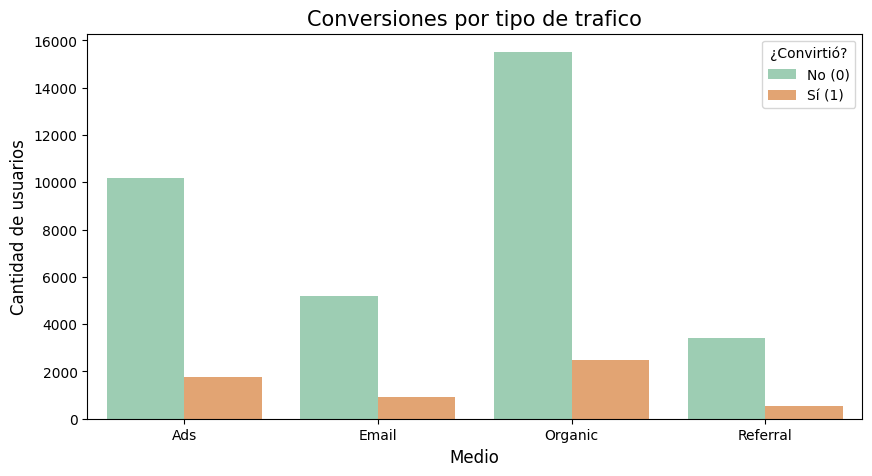

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='traffic_source', hue='converted', palette = ["#95D5B2", "#F4A261"])

# Añadir detalles
plt.title('Conversiones por tipo de trafico', fontsize=15)
plt.xlabel('Medio', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

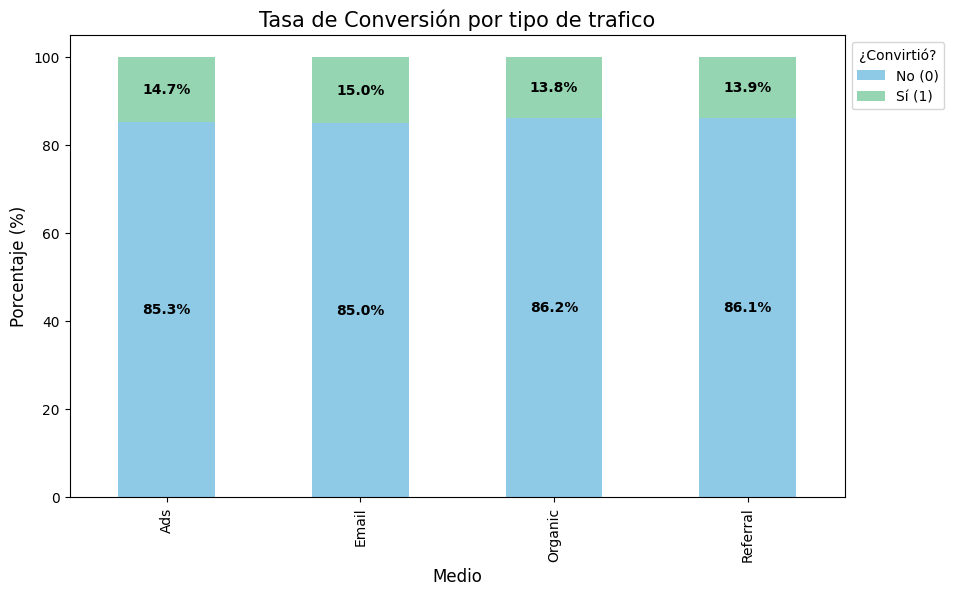

In [ ]:
# Gráfica de barras apiladas
tabla_normalizada = pd.crosstab(df_clean['traffic_source'], df_clean['converted'], normalize='index') * 100
tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por tipo de trafico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Medio', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
# Iterar sobre las barras para pintar los porcentajes numéricos
for convert_type in range(tabla_normalizada.shape[1]):
    for i, bar in enumerate(tabla_normalizada.index):
        # Calcular la altura para saber dónde posicionar el texto
        y_coord = tabla_normalizada.iloc[i, :convert_type].sum() + (tabla_normalizada.iloc[i, convert_type] / 2)
        val = tabla_normalizada.iloc[i, convert_type]

        # Solo pintar si el bloque es lo suficientemente grande
        plt.text(i, y_coord, f"{val:.1f}%", ha='center', va='center', color='black', weight='bold')

plt.show()

El primer gráfico nos mostró que el canal Organic (Orgánico) es, por mucho, el rey del volumen absoluto. Atrae a la mayor cantidad de usuarios hacia la plataforma, seguido por Ads. Los canales de Email y Referral son fuentes mucho más pequeñas en cuanto a cantidad bruta de visitas.

El segundo grafico normalizado cambia la perspectiva por completo al medir la tasa de conversión porcentual (el bloque verde):

- Email lidera la eficiencia con un 15.0% de conversión, seguido muy de cerca por Ads con un 14.7%. Aunque traen menos usuarios en volumen que el tráfico orgánico, las personas que entran por estos dos medios tienen una mayor intención de compra.
- Organic, a pesar de ser el que más gente atrae, tiene la eficiencia más baja con un 13.8%, seguido de cerca por Referral con un 13.9%.

Estamos viendo que "más volumen no siempre significa más eficiencia". Mientras que el tráfico orgánico es excelente para masificar y dar a conocer la marca (gráfico 1), los canales de Email y Ads son significativamente más efectivos para cerrar ventas (gráfico 2). Esto explica perfectamente por qué la prueba de Chi-cuadrado nos dio un resultado significativo: los canales no se comportan igual y las estrategias pagadas/directas están sobre-performando en el embudo de conversión.

### Relación entre el tipo de usuario y la conversión

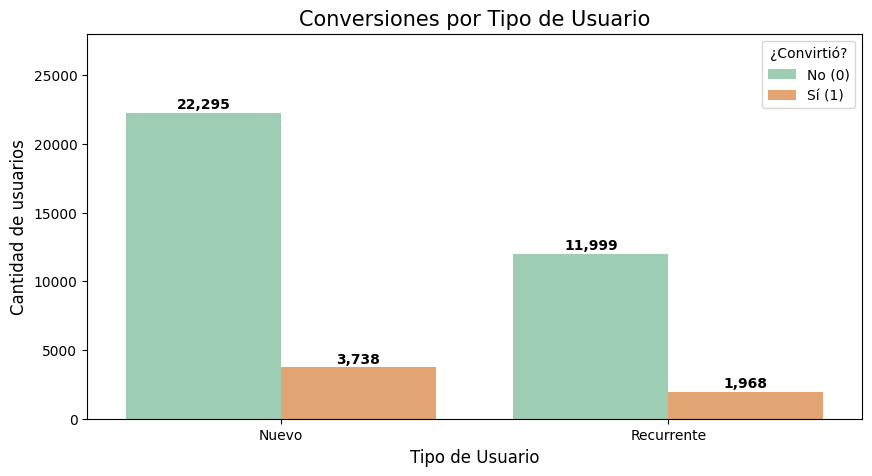

In [ ]:

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_clean, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"])

# Añadir etiquetas con el valor exacto arriba de cada barra
for p in ax.patches:
    if p.get_height() > 0: # Evita pintar si la barra está vacía
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', weight='bold',
                    xytext=(0, 3), textcoords='offset points')

# Corrección de títulos y etiquetas para que coincidan con las variables
plt.title('Conversiones por Tipo de Usuario', fontsize=15)
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Dar un poco más de espacio en el tope del eje Y para que no se corten los números
plt.ylim(0, df_clean['user_type'].value_counts().max() + 2000)

plt.show()


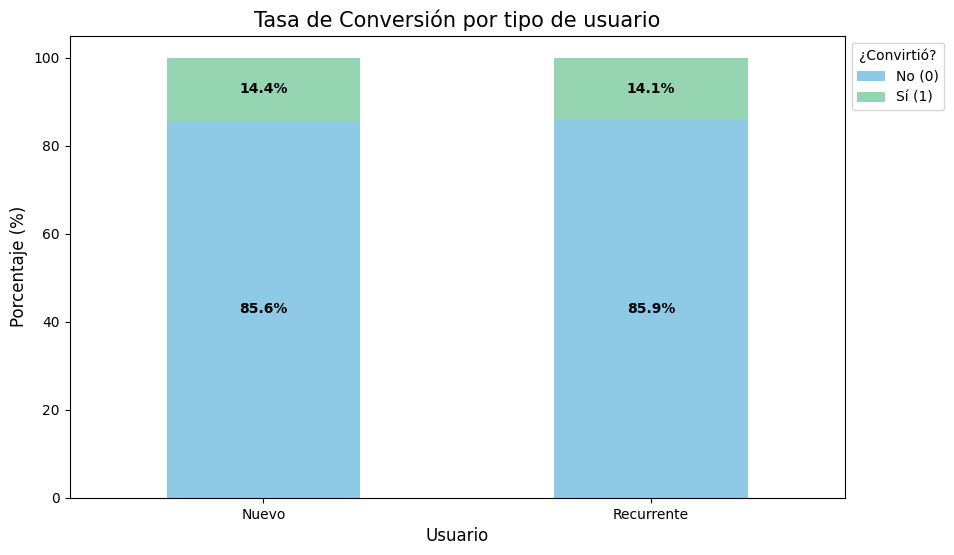

In [ ]:
# Gráfica de barras apiladas
tabla_normalizada = pd.crosstab(df_clean['user_type'], df_clean['converted'], normalize='index') * 100
tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))

# Iterar sobre las barras para pintar los porcentajes numéricos
for convert_type in range(tabla_normalizada.shape[1]):
    for i, bar in enumerate(tabla_normalizada.index):
        # Calcular la altura para saber dónde posicionar el texto
        y_coord = tabla_normalizada.iloc[i, :convert_type].sum() + (tabla_normalizada.iloc[i, convert_type] / 2)
        val = tabla_normalizada.iloc[i, convert_type]

        # Pintar el texto con el porcentaje
        plt.text(i, y_coord, f"{val:.1f}%", ha='center', va='center', color='black', weight='bold')

plt.xticks(rotation=0) # Mantiene los nombres "Nuevo" y "Recurrente" de forma horizontal para mejor lectura
plt.show()

El gráfico de frecuencias absolutas nos muestra que la base de datos está fuertemente inclinada hacia los usuarios Nuevos.Entran casi el doble de usuarios Nuevos ($26,033$ en total, sumando los que convirtieron y los que no) frente a los usuarios Recurrentes ($13,967$ en total).Debido a este enorme volumen, la cantidad neta de conversiones de los Nuevos ($3,738$) triplica visualmente a las conversiones de los Recurrentes ($1,968$).

El gráfico de barras apiladas al 100% quita el "ruido" del volumen y nos muestra la realidad de la tasa de conversión:
- Los usuarios Nuevos convierten a un ritmo del 14.4%.
- Los usuarios Recurrentes convierten a un ritmo del 14.1%.

La diferencia entre ambos es de apenas un 0.3%. Visualmente, las dos barras son espejos la una de la otra.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Métricas de Valor por Cliente: La evaluación financiera previa del gasto promedio por usuario convertido demostró una diferencia en el ticket de compra entre ambas variantes.

- Impacto en Ingresos: El comportamiento del gasto ayuda a determinar si la página con más volumen también atrae transacciones de mayor valor monetario.

- Segmentación del Ticket: El análisis del valor de compra permite identificar si los cambios de diseño incentivan la adquisición de productos premium o compras complementarias.

- **Interpretación:**
La combinación del volumen de transacciones con el gasto promedio define el verdadero ganador financiero. Si la variante líder en conversión mantiene o supera el gasto promedio de la contraparte, se consolida como la opción más rentable para el negocio de forma integral.


---

**Tasa de conversión:**
- Volumen de Éxito Equilibrado: El experimento registró $2,512$ conversiones para la Página A (de un total de $19,982$ usuarios) frente a $3,194$ conversiones para la Página B (de un total de $20,018$ usuarios).
- Evidencia Estadística Contundente: La prueba Z de proporciones arrojó un estadístico $z$ fuertemente negativo de $-9.67$ y un valor p infinitamente bajo de $3.76 \times 10^{-22}$.
- Consistencia en la Muestra: El tamaño balanceado de los grupos de control y tratamiento garantiza que el incremento observado no se deba a anomalías en la distribución del tráfico.

- **Interpretación:**
Se rechaza la hipótesis nula con un nivel de confianza superior al 99.99%. Los datos confirman de forma contundente que la Página B supera significativamente a la Página A en la tasa de conversión. El estadístico $z$ negativo valida matemáticamente que el rediseño o los elementos implementados en la variante B son drásticamente más eficientes para guiar a los usuarios hacia la conversión dentro de las condiciones controladas del test.

---

#### 📊 **Segmentación por fuente de tráfico**
- Desbalance entre Volumen y Eficiencia: El tráfico orgánico (Organic) es el canal que más usuarios atrae en volumen bruto, pero teóricamente sub-performa al registrar $2,480$ conversiones reales frente a las $2,565.8$ esperadas por el modelo matemático. En contraste, las campañas pagadas (Ads) aportaron $1,759$ conversiones (superando las $1,702.5$ esperadas) y las estrategias de correo (Email) alcanzaron $918$ conversiones (sobre las $873.4$ teóricas).
- Dependencia Estadística: La prueba de Chi-cuadrado arrojó un estadístico de $8.662$ con 3 grados de libertad y un valor p de $0.034$, ubicándose por debajo del umbral estándar de significancia ($\alpha = 0.05$).
- Comportamiento en Canales Secundarios: El canal de Referral operó de manera muy cercana a su expectativa teórica ($549$ reales frente a $564.1$ esperadas), mostrando un comportamiento neutral en el ecosistema.

- **Interpretación:**
Existe una asociación estadísticamente significativa (con un 96.60% de confianza) entre el canal de origen del usuario y su propensión a convertir. Los datos demuestran que Ads (14.7%) y Email (15.0%) son los canales más efectivos y eficientes para cerrar ventas en el embudo, mientras que el canal orgánico, a pesar de su masividad, opera con una menor tasa de efectividad real (13.8%).

 ---

#### 📊 **Segmentación por tipo de usuario**
- Homogeneidad en la Conversión: El análisis cruzado evidenció que los usuarios Nuevos convierten a una tasa del 14.4% ($3,738$ conversiones de $26,033$ visitas), mientras que los usuarios Recurrentes lo hacen a un ritmo del 14.1% ($1,968$ conversiones de $13,967$ visitas).
- Independencia Confirmada: La prueba de Chi-cuadrado para estas variables arrojó un estadístico de $0.513$ con 1 grado de libertad y un valor p de $0.474$, superando por amplio margen el umbral $\alpha = 0.05$.
- Alineación con la Expectativa: El número de conversiones reales en ambos grupos calcó casi a la perfección las frecuencias esperadas por el azar ($3,738$ vs $3,713.6$ en Nuevos; $1,968$ vs $1,992.3$ en Recurrentes), consolidando la ausencia de fricción o preferencia según la antigüedad del perfil.

- **Interpretación:**
No se rechaza la hipótesis nula, lo que significa que el tipo de usuario y la conversión son variables estadísticamente independientes. Aunque el negocio atrae casi el doble de usuarios nuevos en volumen bruto, ambos perfiles se comportan exactamente igual ante la plataforma. Las estrategias de persuasión digital impactan con la misma efectividad tanto a un usuario que entra por primera vez como a uno que regresa.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Implementación Definitiva de la Variante B: Se recomienda realizar el despliegue permanente de la Página B a nivel global, dado su liderazgo estadístico incuestionable en la generación de conversiones.
- Redirección de Presupuesto a Canales de Alta Intención: Optimizar la inversión de marketing incrementando el presupuesto hacia campañas de Ads y flujos de automatización de Email. Al haber demostrado una eficiencia superior a la expectativa teórica, garantizan un mejor retorno de inversión por cada usuario atraído.
- Auditoría y Optimización del Tráfico Orgánico: Implementar una revisión de la estrategia SEO y del perfil de usuario atraído por el canal Organic. Dado que es la fuente con mayor volumen pero menor tasa de cierre, se requiere refinar las palabras clave o el contenido para atraer tráfico con una mayor intención de compra real.
- Estrategia de Comunicación Unificada por Perfil: Mantener una infraestructura de conversión estándar para usuarios Nuevos y Recurrentes, ya que responden con la misma efectividad. No es prioritario en esta etapa desarrollar embudos de conversión drásticamente especializados o complejos según la antigüedad del usuario.

⚠️ Este análisis ejecutivo demuestra correlaciones y dependencias estadísticas sólidas y altamente significativas bajo las condiciones controladas del experimento. Sin embargo, este reporte no asegura causalidad directa ni descarta por completo la influencia latente de variables externas intervinientes, estacionalidades del mercado o factores sociodemográficos que pudieran haber interactuado de forma asimétrica con los datos durante su recolección.